In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [ ]:
df1 = pd.read_csv('F1drivers_2022_2025_one_two_stop.csv')
df1.head()

,DriverNumber,TeamName,Position,ClassifiedPosition,GridPosition,Points,Season,EventName,EventDate,PitstopCount,...,Overtakes,DriverFastestLap_s,AvgLapTime_s,AvgSpeedTrap_kmh,TrackTemp_Mean,AirTemp_Mean,Humidity_Mean,WindSpeed_Mean,Rainfall_Amount,WeatherConditions
0,81,Oscar_Piastri,1,1.0,1,25,2025,Chinese Grand Prix,3/23/25,1,...,2,95.520,97.411179,314.267857,35.816883,27.215584,18.233766,2.188312,0,Clear
1,4,Lando_Norris,2,2.0,3,18,2025,Chinese Grand Prix,3/23/25,1,...,3,95.454,97.585250,313.964286,35.816883,27.215584,18.233766,2.188312,0,Clear
2,63,George_Russell,3,3.0,2,15,2025,Chinese Grand Prix,3/23/25,1,...,2,95.816,97.609339,319.803571,35.816883,27.215584,18.233766,2.188312,0,Clear
3,1,Max_Verstappen,4,4.0,4,12,2025,Chinese Grand Prix,3/23/25,1,...,6,95.488,97.708607,316.946429,35.816883,27.215584,18.233766,2.188312,0,Clear
4,31,Esteban_Ocon,5,5.0,11,10,2025,Chinese Grand Prix,3/23/25,1,...,9,95.740,98.303482,316.642857,35.816883,27.215584,18.233766,2.188312,0,Clear


In [ ]:
df2 = df1.drop(['DriverNumber','Season','EventName','EventDate', 'TireStrategy0'], axis = 1)
df2.head()

,TeamName,Position,ClassifiedPosition,GridPosition,Points,PitstopCount,TireStrategy,Overtakes,DriverFastestLap_s,AvgLapTime_s,AvgSpeedTrap_kmh,TrackTemp_Mean,AirTemp_Mean,Humidity_Mean,WindSpeed_Mean,Rainfall_Amount,WeatherConditions
0,Oscar_Piastri,1,1.0,1,25,1,MEDIUM_HARD,2,95.520,97.411179,314.267857,35.816883,27.215584,18.233766,2.188312,0,Clear
1,Lando_Norris,2,2.0,3,18,1,MEDIUM_HARD,3,95.454,97.585250,313.964286,35.816883,27.215584,18.233766,2.188312,0,Clear
2,George_Russell,3,3.0,2,15,1,MEDIUM_HARD,2,95.816,97.609339,319.803571,35.816883,27.215584,18.233766,2.188312,0,Clear
3,Max_Verstappen,4,4.0,4,12,1,MEDIUM_HARD,6,95.488,97.708607,316.946429,35.816883,27.215584,18.233766,2.188312,0,Clear
4,Esteban_Ocon,5,5.0,11,10,1,MEDIUM_HARD,9,95.740,98.303482,316.642857,35.816883,27.215584,18.233766,2.188312,0,Clear


In [ ]:
df2['TeamName'] = df2['TeamName'].astype(str)
df3 = pd.get_dummies(df2, drop_first = False)
df3.head()

,Position,ClassifiedPosition,GridPosition,Points,PitstopCount,Overtakes,DriverFastestLap_s,AvgLapTime_s,AvgSpeedTrap_kmh,TrackTemp_Mean,...,TeamName_Pierre_Gasly,TeamName_Yuki_Tsunoda,TireStrategy_HARD_MEDIUM,TireStrategy_HARD_SOFT,TireStrategy_MEDIUM_HARD,TireStrategy_SOFT_HARD,TireStrategy_SOFT_MEDIUM,WeatherConditions_Clear,WeatherConditions_Rainy,WeatherConditions_Windy
0,1,1.0,1,25,1,2,95.520,97.411179,314.267857,35.816883,...,False,False,False,False,True,False,False,True,False,False
1,2,2.0,3,18,1,3,95.454,97.585250,313.964286,35.816883,...,False,False,False,False,True,False,False,True,False,False
2,3,3.0,2,15,1,2,95.816,97.609339,319.803571,35.816883,...,False,False,False,False,True,False,False,True,False,False
3,4,4.0,4,12,1,6,95.488,97.708607,316.946429,35.816883,...,False,False,False,False,True,False,False,True,False,False
4,5,5.0,11,10,1,9,95.740,98.303482,316.642857,35.816883,...,False,False,False,False,True,False,False,True,False,False


In [ ]:
X = df3.drop('Points', axis = 1)
y = df3['Points']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
# Creating the string for the formula
col_string = ' + '.join(X_train.columns)
col_string

'Position + ClassifiedPosition + GridPosition + PitstopCount + Overtakes + DriverFastestLap_s + AvgLapTime_s + AvgSpeedTrap_kmh + TrackTemp_Mean + AirTemp_Mean + Humidity_Mean + WindSpeed_Mean + Rainfall_Amount + TeamName_Alexander_Albon + TeamName_Carlos_Sainz + TeamName_Charles_Leclerc + TeamName_Esteban_Ocon + TeamName_Fernando_Alonso + TeamName_Franco_Colapinto + TeamName_Gabriel_Bortoleto + TeamName_George_Russell + TeamName_Isack_Hadjar + TeamName_Kimi_Antonelli + TeamName_Lance_Stroll + TeamName_Lando_Norris + TeamName_Lewis_Hamilton + TeamName_Liam_Lawson + TeamName_Max_Verstappen + TeamName_Nico_Hulkenberg + TeamName_Oliver_Bearman + TeamName_Oscar_Piastri + TeamName_Pierre_Gasly + TeamName_Yuki_Tsunoda + TireStrategy_HARD_MEDIUM + TireStrategy_HARD_SOFT + TireStrategy_MEDIUM_HARD + TireStrategy_SOFT_HARD + TireStrategy_SOFT_MEDIUM + WeatherConditions_Clear + WeatherConditions_Rainy + WeatherConditions_Windy'

In [ ]:
# Linear regression model
lin_reg_model = smf.ols(formula = 'Points ~ ' + col_string, data = pd.concat([X_train, y_train], axis=1))
lin_reg_model_results = lin_reg_model.fit()
print(lin_reg_model_results.summary())

                            OLS Regression Results                            
Dep. Variable:                 Points   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     95.94
Date:                Sat, 29 Nov 2025   Prob (F-statistic):          2.24e-215
Time:                        03:33:19   Log-Likelihood:                -1447.8
No. Observations:                 594   AIC:                             2972.
Df Residuals:                     556   BIC:                             3138.
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

In [ ]:
# Creating varaibles to store the actual points and predictions
y_train_points = y_train.copy()
y_train_pred = lin_reg_model_results.predict(X_train)
y_test_points = y_test.copy()
y_test_pred = lin_reg_model_results.predict(X_test)

In [ ]:
# Calculating the SSE and SST, and calculate R^2 for training dataset
train_SSE = np.sum((y_train_points - y_train_pred)**2)
train_SST = np.sum((y_train_points - y_train_pred.mean())**2)
train_R2 = 1 - train_SSE/train_SST
print("Training set R^2 " + str(round(train_R2, 4)))

Training set R^2 0.8721


In [ ]:
# Calculating the SSE and SST, and calculate R^2 for test dataset
test_SSE = np.sum((y_test_points - y_test_pred)**2)
test_SST = np.sum((y_test_points - y_test_pred.mean())**2)
test_R2 = 1 - test_SSE/test_SST
print("Test set R^2 " + str(round(test_R2, 4)))

Test set R^2 0.8919


In [ ]:
# Pulling out the team columns to do prediction analysis
team_cols = [col for col in X_train.columns if col.startswith('TeamName_')]
print(team_cols)

['TeamName_Alexander_Albon', 'TeamName_Carlos_Sainz', 'TeamName_Charles_Leclerc', 'TeamName_Esteban_Ocon', 'TeamName_Fernando_Alonso', 'TeamName_Franco_Colapinto', 'TeamName_Gabriel_Bortoleto', 'TeamName_George_Russell', 'TeamName_Isack_Hadjar', 'TeamName_Kimi_Antonelli', 'TeamName_Lance_Stroll', 'TeamName_Lando_Norris', 'TeamName_Lewis_Hamilton', 'TeamName_Liam_Lawson', 'TeamName_Max_Verstappen', 'TeamName_Nico_Hulkenberg', 'TeamName_Oliver_Bearman', 'TeamName_Oscar_Piastri', 'TeamName_Pierre_Gasly', 'TeamName_Yuki_Tsunoda']


In [ ]:
weather_encoded_cols = [col for col in X_train.columns if col.startswith('WeatherConditions_')]
weather_types = [col.replace('WeatherConditions_', '') for col in weather_encoded_cols]

tire_strategy_encoded_cols = [col for col in X_train.columns if col.startswith('TireStrategy_')]
tire_strategies = [col.replace('TireStrategy_', '') for col in tire_strategy_encoded_cols]

# With drop_first=False, all categories are explicitly encoded, so there is no 'base' category to infer.
# We set base_weather and base_tire_strategy to None so that the create_scenario_df function correctly
# activates the chosen dummy variable, as 'weather_type != None' will always be true for a valid weather_type.
base_weather = None
base_tire_strategy = None

print(f"All weather types: {weather_types}")
print(f"All tire strategies: {tire_strategies}")

All weather types: ['Clear', 'Rainy', 'Windy']
All tire strategies: ['HARD_MEDIUM', 'HARD_SOFT', 'MEDIUM_HARD', 'SOFT_HARD', 'SOFT_MEDIUM']


In [ ]:
def create_scenario_df(weather_type, tire_strategy, X_train, weather_encoded_cols, tire_strategy_encoded_cols, base_weather, base_tire_strategy):
    # Create a new DataFrame called scenario_df by calculating the mean of each column in X_train
    scenario_df = pd.DataFrame(X_train.mean()).T

    # Iterate through weather_encoded_cols and set the corresponding columns in scenario_df to False.
    for col in weather_encoded_cols:
        scenario_df[col] = False

    # Iterate through tire_strategy_encoded_cols and set the corresponding columns in scenario_df to False.
    for col in tire_strategy_encoded_cols:
        scenario_df[col] = False

    # If the provided weather_type is not equal to the base_weather, set the column f'WeatherConditions_{weather_type}' in scenario_df to True.
    if weather_type != base_weather:
        weather_col_name = f'WeatherConditions_{weather_type}'
        if weather_col_name in scenario_df.columns:
            scenario_df[weather_col_name] = True

    # If the provided tire_strategy is not equal to the base_tire_strategy, set the column f'TireStrategy_{tire_strategy}' in scenario_df to True.
    if tire_strategy != base_tire_strategy:
        tire_strategy_col_name = f'TireStrategy_{tire_strategy}'
        if tire_strategy_col_name in scenario_df.columns:
            scenario_df[tire_strategy_col_name] = True

    # After setting the boolean flags, iterate through all columns in scenario_df and explicitly cast each column to match the data type of its corresponding column in X_train.
    for col in scenario_df.columns:
        if col in X_train.columns:
            scenario_df[col] = scenario_df[col].astype(X_train[col].dtype)

    return scenario_df

In [ ]:
prediction_matrices = {}

# Get unique team names
unique_team_names = [col.replace('TeamName_', '') for col in team_cols]

for current_weather_type in weather_types:
    # Create an empty DataFrame for the current weather type
    weather_matrix = pd.DataFrame(index=unique_team_names, columns=tire_strategies)

    for current_tire_strategy in tire_strategies:
        # Generate a base scenario DataFrame for the current weather and tire strategy
        base_scenario_df = create_scenario_df(
            current_weather_type,
            current_tire_strategy,
            X_train,
            weather_encoded_cols,
            tire_strategy_encoded_cols,
            base_weather,
            base_tire_strategy
        )

        team_predictions = {}
        for team_col in team_cols:
            # Create a copy of the base scenario for each team
            scenario_for_team = base_scenario_df.copy()

            # Set the current team's one-hot encoded column to True
            scenario_for_team[team_col] = True

            # Set all other team columns to False
            for other_team_col in team_cols:
                if other_team_col != team_col:
                    scenario_for_team[other_team_col] = False

            # Predict points for the current team scenario
            predicted_points = lin_reg_model_results.predict(scenario_for_team)[0]
            team_name = team_col.replace('TeamName_', '')
            team_predictions[team_name] = predicted_points

        # Populate the weather_matrix for the current tire strategy column
        weather_matrix[current_tire_strategy] = pd.Series(team_predictions)

    # Store the completed weather matrix
    prediction_matrices[current_weather_type] = weather_matrix

In [ ]:
# Print each prediction matrix with a descriptive header, sorted by maximum predicted points per driver
for weather, matrix in prediction_matrices.items():
    print(f"\nPrediction Matrix for {weather} Weather (Sorted by Max Points):")

    # Calculate the maximum predicted points for each driver across all tire strategies
    # This will be used for sorting the drivers (rows)
    matrix_with_max_points = matrix.copy()
    matrix_with_max_points['Max_Predicted_Points'] = matrix_with_max_points.max(axis=1)

    # Sort the matrix by the 'Max_Predicted_Points' column in descending order
    sorted_matrix = matrix_with_max_points.sort_values(by='Max_Predicted_Points', ascending=False)

    # Drop the temporary 'Max_Predicted_Points' column before printing
    sorted_matrix = sorted_matrix.drop(columns=['Max_Predicted_Points'])

    print(sorted_matrix.round(2))


Prediction Matrix for Clear Weather (Sorted by Max Points):
                   HARD_MEDIUM  HARD_SOFT  MEDIUM_HARD  SOFT_HARD  SOFT_MEDIUM
Max_Verstappen           11.91      13.75        11.55      11.17        12.97
Lando_Norris              8.94      10.77         8.58       8.20        10.00
Oscar_Piastri             8.23      10.07         7.87       7.49         9.30
Charles_Leclerc           8.01       9.85         7.65       7.27         9.07
George_Russell            7.57       9.41         7.21       6.83         8.63
Franco_Colapinto          7.54       9.38         7.19       6.80         8.61
Lewis_Hamilton            7.22       9.06         6.86       6.48         8.29
Gabriel_Bortoleto         7.13       8.97         6.77       6.39         8.19
Carlos_Sainz              7.12       8.96         6.76       6.38         8.18
Kimi_Antonelli            6.81       8.65         6.45       6.07         7.87
Lance_Stroll              6.47       8.30         6.11       5.73     

In [ ]:
for weather, matrix in prediction_matrices.items():
    print(f"\nTop-performing teams for {weather} Weather:")
    if matrix.empty:
        print("  No predictions available for this weather type as the prediction matrix is empty.")
        continue
    # Iterate through each tire strategy (column) to find the max points and corresponding team
    for strategy in matrix.columns:
        # Check if the column (Series) is empty before calling idxmax()
        if not matrix[strategy].empty:
            top_team_idx = matrix[strategy].idxmax()
            max_points = matrix[strategy].max()
            print(f"  {strategy}: {top_team_idx} with {max_points:.2f} points")
        else:
            print(f"  No predictions for strategy {strategy} as the column is empty.")


Top-performing teams for Clear Weather:
  HARD_MEDIUM: Max_Verstappen with 11.91 points
  HARD_SOFT: Max_Verstappen with 13.75 points
  MEDIUM_HARD: Max_Verstappen with 11.55 points
  SOFT_HARD: Max_Verstappen with 11.17 points
  SOFT_MEDIUM: Max_Verstappen with 12.97 points

Top-performing teams for Rainy Weather:
  HARD_MEDIUM: Max_Verstappen with 12.60 points
  HARD_SOFT: Max_Verstappen with 14.44 points
  MEDIUM_HARD: Max_Verstappen with 12.25 points
  SOFT_HARD: Max_Verstappen with 11.86 points
  SOFT_MEDIUM: Max_Verstappen with 13.67 points

Top-performing teams for Windy Weather:
  HARD_MEDIUM: Max_Verstappen with 11.82 points
  HARD_SOFT: Max_Verstappen with 13.66 points
  MEDIUM_HARD: Max_Verstappen with 11.46 points
  SOFT_HARD: Max_Verstappen with 11.08 points
  SOFT_MEDIUM: Max_Verstappen with 12.88 points


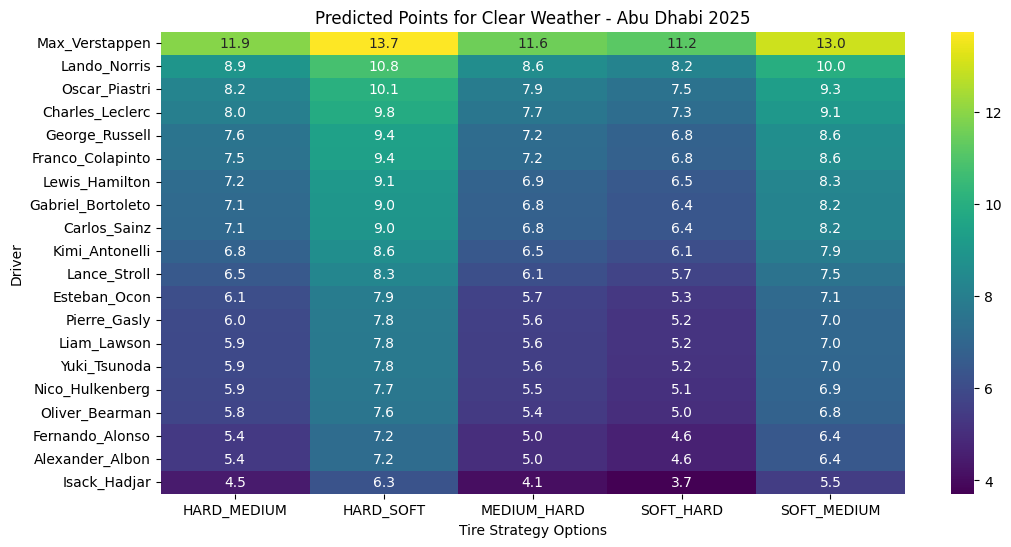

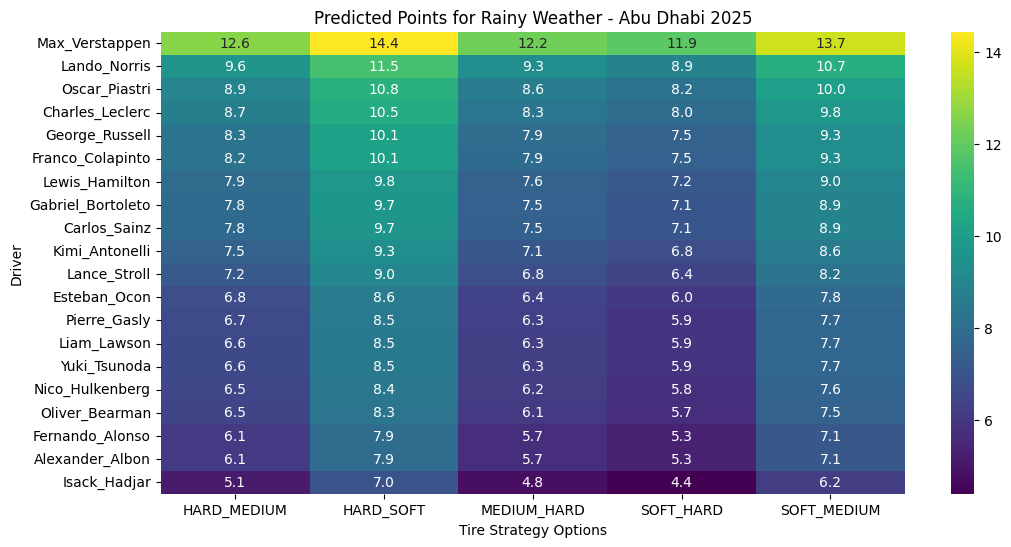

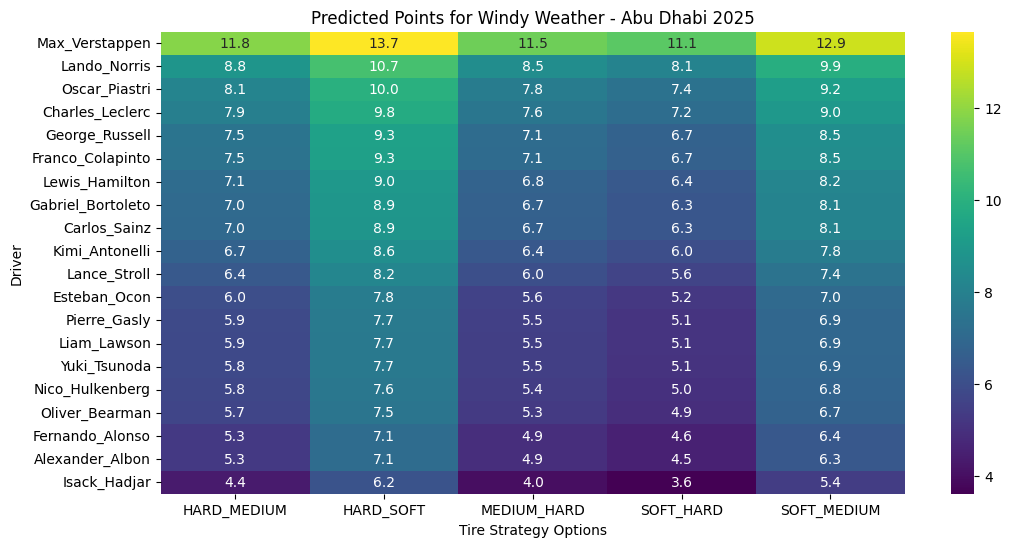

In [ ]:
for weather, matrix in prediction_matrices.items():
    # Calculate the maximum predicted points for each driver across all tire strategies
    matrix_with_max_points = matrix.copy()
    matrix_with_max_points['Max_Predicted_Points'] = matrix_with_max_points.max(axis=1)

    # Sort the matrix by the 'Max_Predicted_Points' column in descending order
    sorted_matrix_by_driver = matrix_with_max_points.sort_values(by='Max_Predicted_Points', ascending=False)

    # Drop the temporary 'Max_Predicted_Points' column
    sorted_matrix_by_driver = sorted_matrix_by_driver.drop(columns=['Max_Predicted_Points'])

    # Sort the columns (tire strategies) alphabetically for consistent plot layout
    sorted_columns = sorted(sorted_matrix_by_driver.columns)
    matrix_to_plot = sorted_matrix_by_driver[sorted_columns]

    plt.figure(figsize=(12, 6))
    sns.heatmap(matrix_to_plot, annot=True, fmt=".1f", cmap="viridis")
    plt.title(f'Predicted Points for {weather} Weather - Abu Dhabi 2025')
    plt.xlabel('Tire Strategy Options')
    plt.ylabel('Driver')
    plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate MSE, RMSE, and MAE for the training set
# Filter out NaN values from both actual and predicted points
valid_train_indices = ~np.isnan(y_train_points) & ~np.isnan(y_train_pred)
train_mse = mean_squared_error(y_train_points[valid_train_indices], y_train_pred[valid_train_indices])
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train_points[valid_train_indices], y_train_pred[valid_train_indices])

print(f"Training MSE: {train_mse:.4f}")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Training MAE: {train_mae:.4f}")

Training MSE: 7.6664
Training RMSE: 2.7688
Training MAE: 2.1490


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate MSE, RMSE, and MAE for the test set
# Filter out NaN values from both actual and predicted points
valid_test_indices = ~np.isnan(y_test_points) & ~np.isnan(y_test_pred)
test_mse = mean_squared_error(y_test_points[valid_test_indices], y_test_pred[valid_test_indices])
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test_points[valid_test_indices], y_test_pred[valid_test_indices])

print(f"Test MSE: {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Test MSE: 8.6545
Test RMSE: 2.9419
Test MAE: 2.3119


In [ ]:
SSE = np.sum((y_test - y_test_pred)**2)
print(SSE)

1324.1457523388838


In [ ]:
SST = np.sum((y_test - df3['Points'].mean())**2)
print(SST)
R2 = 1 - SSE/SST
print(R2)

12451.667672955973
0.8936571560438589
